### 加载数据

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
set_config(transform_output="pandas")
init_logger("Simulation_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\Simulation_252.log


In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2116 只 | 2579 天 | 2016-01-04 ~ 2026-08-14
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2578 天 x 2112 资产 | 列集一致: True


### 参数搜索
- Walkforward:
    - CombinatorialPurgedCV

In [3]:
from wf_cpcv_search import load_nested_config
from cpcv_search_base import build_pipeline_src
from walkforward_parameter_search import compute_grid_size
from wf_cpcv_search import nested_adaptive_search, adaptive_multi_paths, build_test_parts, summarize_fold_params,summarize_top_k_params
from cpcv_analysis import discrete_lhs_safe, diagnose_oos_lhs, report_ann_distribution, turnover_series
from cpcv_analysis import plot_oos_vs_bench,excess_vs_bench, plot_paths_curve
from wf_cpcv_robustness import (perturbation_mc, sensitivity_curves, sensitivity_heatmap, topk_paths_eval,)
from wf_cpcv_ablation import ablate

In [4]:
log_print("mean(Annualized Sharpe Ratio)/2 - mean(MAXDD) + mean(SKEW)", section='Ojective', echo=False)
log_print(build_pipeline_src(), section="Model Pipeline", echo=False)

In [5]:
search_space = {'nondomin__min_n_assets': {'low': 5, 'high': 55, 'step': 5},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.5, 'step': 0.1},
 'extremes__k': {'low': 0.1, 'high': 0.6, 'step': 0.1},
 'nondomin__fitness_measures': [
    "mean-variance-kurt",
    "mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    "mean-semideviation-avgdd",
    "mean-mad-maxdd-kurt",
    "mean-mad-avgdd-kurt",
    "mean-mad-maxdd-cvar-kurt",
    "mean-mad-maxdd-cvar-sharpe",
    "mean-mad-avgdd-cvar-kurt",
    "mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 126}}  # inner train size
log_print(search_space, section='Parameter Space', echo=False)
compute_grid_size(search_space)

49500

In [6]:
search_params = {'test_size': 252,
  'train_size': 756+252,
  'n_test_folds': 2,
  'n_jobs': 4,
  'cv_n_jobs': 12,
  'n_trials': 2000,
  'patience': 100,
  'sampler': 'tpe',
  'min_delta': 0.0001,
  'outer_purged_size': 0,
  'outer_reduce_test': False,
  'seed': 42,
  'verbose': True}
log_print(search_params, section="Search Parameter", echo=False)

In [7]:
fold_results = nested_adaptive_search(X,space=search_space, **search_params)

  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 0: mean score=1.0496 | test_ann=0.0916 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 1: mean score=0.7922 | test_ann=-0.0310 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

...

Fold 3: mean score=0.5029 | test_ann=0.0667 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 4: mean score=0.5262 | test_ann=0.0408 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 5: mean score=0.6090 | test_ann=0.1411 | test_days=252


### Step 1 | IS 审计：每折 P Luck + Top-K 候选
- dsr = 该折最优分数超过"纯运气挑最优"基准的经验概率（H0 噪声 MC deflate，N = 参数去重后的真实试验数）。 margin = sr_obs − E[max_N]，max_p95 为运气基准 95% 分位。
- gap2top1（summarize_top_k_params 的列）= IS 侧 top1 与 top2 的分数落差： 落差小 → 参数处在平台（好信号）；落差大 → top1 可能是运气孤峰（坏信号）。

In [8]:
log_print(summarize_fold_params(fold_results).to_string(),section='Best Parameter', echo=True)

   fold   score  p_luck  margin  train ASR  test ASR  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                     fitness  n_trials
0     0  1.0496  0.1165  0.0819     1.7363    1.0505                      45                 -0.4                   0.2          0.6         378  mean-mad-maxdd-cvar-sharpe        76
1     1  0.7922  0.9449 -0.0852     1.2036   -0.4565                      55                 -0.3                   0.2          0.5         252    mean-mad-avgdd-cvar-kurt        81
2     2  0.3697  0.7757 -0.0332     1.3122    0.2697                      50                 -0.4                   0.2          0.5         252    mean-semideviation-avgdd        85
3     3  0.5029  0.8893 -0.1139     0.7169    0.9795                      40                 -0.5                   0.1          0.5         504    mean-semideviation-avgdd        89
4     4  0.5262  0.2914  0.0355     0.7856    0.4264                      15         

In [9]:
topk = summarize_top_k_params(fold_results, k=5)         # 行 = (fold, rank)
print(topk[topk["rank"] <= 3][['fold','rank','score','gap2top1']])                    # 每折 top1/top2 候选 + gap2top1

    fold  rank   score  gap2top1
0      0     1  1.0496    0.0000
1      0     2  0.8969    0.1527
2      0     3  0.8906    0.1590
5      1     1  0.7922    0.0000
6      1     2  0.7922    0.0000
7      1     3  0.7922    0.0000
10     2     1  0.3697    0.0000
11     2     2  0.3604    0.0093
12     2     3  0.3450    0.0247
15     3     1  0.5029    0.0000
16     3     2  0.4868    0.0161
17     3     3  0.4830    0.0198
20     4     1  0.5262    0.0000
21     4     2  0.4568    0.0694
22     4     3  0.4504    0.0758
25     5     1  0.6090    0.0000
26     5     2  0.6090    0.0000
27     5     3  0.6090    0.0000


### Step 2｜过拟合判据：DSR 低 + OOS 衰减
- 判据：WFE > 0.5 为稳健泛化（多数折满足）。
- "DSR 低 + OOS 显著下降" = 内层选择偏差校正后无真实优势 + 样本外掉队 → 该折结论不可信，

In [11]:
df = summarize_fold_params(fold_results).copy()
df["WFE"] = df["test ASR"] / df["train ASR"]      # 每折 IS→OOS 衰减比
df["flag"] = (df["p_luck"] > 0.5) & (df["WFE"] < 0.5)   # 运气嫌疑高 + 衰减 = 过拟合嫌疑折
print(df[["fold", "p_luck", "train ASR", "test ASR", "WFE", "flag"]])

   fold  p_luck  train ASR  test ASR       WFE   flag
0     0  0.1165     1.7363    1.0505  0.605022  False
1     1  0.9449     1.2036   -0.4565 -0.379279   True
2     2  0.7757     1.3122    0.2697  0.205533   True
3     3  0.8893     0.7169    0.9795  1.366299  False
4     4  0.2914     0.7856    0.4264  0.542770  False
5     5  0.9877     1.0130    0.9349  0.922902  False


### Step 3｜Top-K 候选 OOS 多路径压测
- 窗口自动从 folds 推导（折位 1:1）；如需 notebook 原压测口径（如 `n_test_folds=4`），
  以显式键传入：`topk_paths_eval(X, folds, paths_kwargs={"n_test_folds": 4})`。
- 价值在**参数高原的 OOS 侧印证**：gap2top1 小的候选若 OOS 同样接近，说明生产参数处在稳定平台。

In [12]:
eval_ = topk_paths_eval(X, fold_results, k=10)            # 每折 top1~5 全部进 CPCV 多路径压测

rank1: 完整OOS路径 | 6 折拼接 | 1512 天
rank2: 完整OOS路径 | 6 折拼接 | 1512 天
rank3: 完整OOS路径 | 6 折拼接 | 1512 天
rank4: 完整OOS路径 | 6 折拼接 | 1512 天
rank5: 完整OOS路径 | 6 折拼接 | 1512 天
rank6: 完整OOS路径 | 6 折拼接 | 1512 天
rank7: 完整OOS路径 | 6 折拼接 | 1512 天
rank8: 完整OOS路径 | 6 折拼接 | 1512 天
rank9: 完整OOS路径 | 6 折拼接 | 1512 天
rank10: 完整OOS路径 | 6 折拼接 | 1512 天


In [13]:

paths = eval_["paths"]                            # MultiIndex (fold, rank, path)
audit = eval_["audit"]                            # IS 侧审计，与 paths 按 (fold, rank) 对齐
sharpe = paths["annualized_sharpe_ratio"].groupby("rank").mean()
print(sharpe)              # rank 均值对比（不选参，只看高原）

rank
1     0.590523
2     0.765230
3     0.837964
4     0.828797
5     0.850010
6     1.051931
7     0.968725
8     0.966537
9     0.551333
10    1.050565
Name: annualized_sharpe_ratio, dtype: float64


In [14]:
log_print(paths, section="Top 10 参数组合OOS:ASR,MEAN,MAXDD")

      annualized_sharpe_ratio  annualized_mean  max_drawdown
rank                                                        
1                    0.590523         0.054529      0.127776
2                    0.765230         0.074197      0.142424
3                    0.837964         0.080143      0.189996
4                    0.828797         0.085078      0.188993
5                    0.850010         0.088650      0.141298
6                    1.051931         0.110877      0.137733
7                    0.968725         0.114860      0.124164
8                    0.966537         0.095172      0.088020
9                    0.551333         0.080651      0.247268
10                   1.050565         0.096646      0.088020


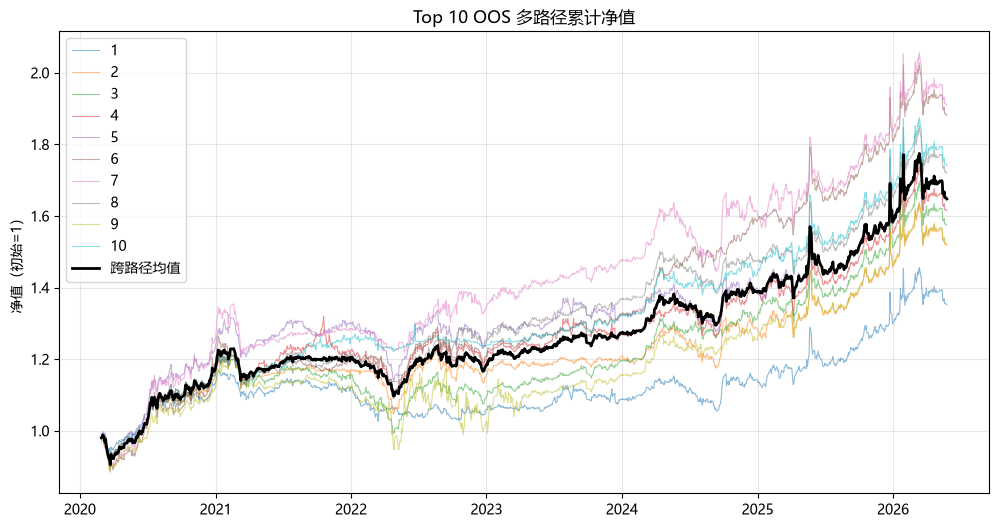

In [15]:
top_k_mpts = Population([mpt for mpt in eval_['mpts'].values()])
plot_paths_curve(top_k_mpts, title='Top 10 OOS 多路径累计净值', labels=[k for k in eval_['mpts'].keys()])

### Ensemble

In [16]:
from wf_topk_ensemble import topk_ensemble_eval

In [17]:
ens = topk_ensemble_eval(X, fold_results, k=5) 

Fold 0: 候选=5 | top1资产=9 | 融合池=17（重叠=9）| top1_test=1.0505 | ens_test=1.7797
Fold 1: 候选=5 | top1资产=6 | 融合池=10（重叠=6）| top1_test=-0.4565 | ens_test=0.5563
Fold 2: 候选=5 | top1资产=6 | 融合池=15（重叠=6）| top1_test=0.2697 | ens_test=0.5219
Fold 3: 候选=5 | top1资产=4 | 融合池=6（重叠=4）| top1_test=0.9795 | ens_test=1.5572
Fold 4: 候选=5 | top1资产=6 | 融合池=10（重叠=6）| top1_test=0.4264 | ens_test=0.7575
Fold 5: 候选=5 | top1资产=3 | 融合池=3（重叠=3）| top1_test=0.9349 | ens_test=1.0160
完整 OOS 路径: 6 折拼接, 共 1512 天


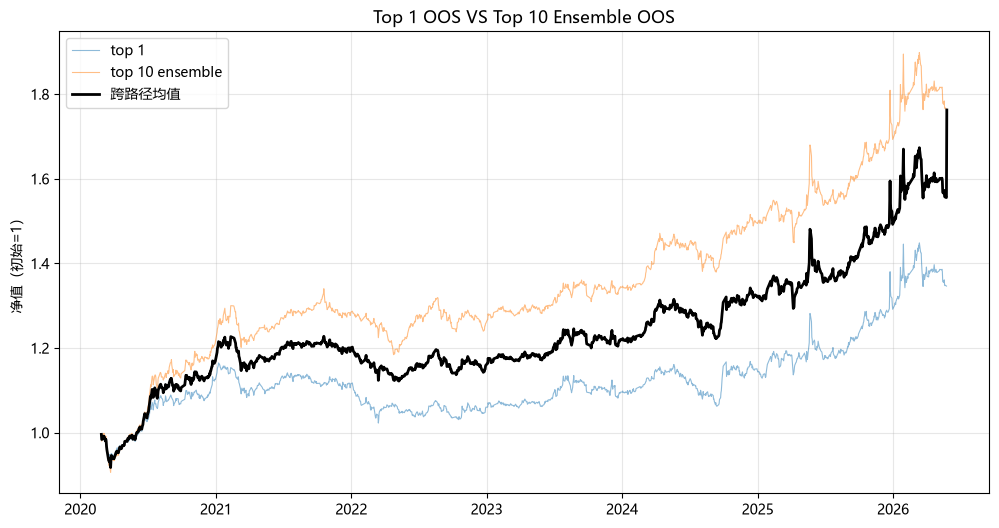

In [18]:
ensemble_mpt = Population([ens['paths']['top1'], ens['paths']['ensemble']])
plot_paths_curve(ensemble_mpt, title='Top 1 OOS VS Top 10 Ensemble OOS', labels=['top 1','top 10 ensemble'])

In [21]:
log_print(ens['paths']['ensemble'].summary(),section='Top K Ensemble OSS Summary',echo=False)

### Step 4｜单参数敏感性曲线
- 每折只动目标参数、其余保持生产值（fitness 固定 top1）；`frac=0` 档即生产值本身（锚点）。
- 默认覆盖**全部数值参数含 `train_size`**（它是搜索维度之一，扰动后评估即用扰动后的拟合窗口长度）。
- 读图：参数高原 = ±30% 内绩效平缓；孤峰 = 仅生产值附近突出（与 IS 侧 gap2top1 互证）。
- 只评估单折 OOS → 无 CPCV 展开，成本低，可全参数全档位跑。

In [16]:
curves = sensitivity_curves(X, fold_results, reduce_test=False)             # 默认 ±10/20/30% 六档 × 全部数值参数
c = curves[curves["param"] == "extremes__k"]
ax = c.pivot_table(index="frac", columns="fold",
                   values="annualized_sharpe_ratio").plot(marker="o")

Fold 0: 单参网格完成 (5 参数 × 6 档)
Fold 1: 单参网格完成 (5 参数 × 6 档)
Fold 2: 单参网格完成 (5 参数 × 6 档)
Fold 3: 单参网格完成 (5 参数 × 6 档)
Fold 4: 单参网格完成 (5 参数 × 6 档)
Fold 5: 单参网格完成 (5 参数 × 6 档)
Fold 6: 单参网格完成 (5 参数 × 6 档)
Fold 7: 单参网格完成 (5 参数 × 6 档)
Fold 8: 单参网格完成 (5 参数 × 6 档)
Fold 9: 单参网格完成 (5 参数 × 6 档)
Fold 10: 单参网格完成 (5 参数 × 6 档)
Fold 11: 单参网格完成 (5 参数 × 6 档)
Fold 12: 单参网格完成 (5 参数 × 6 档)


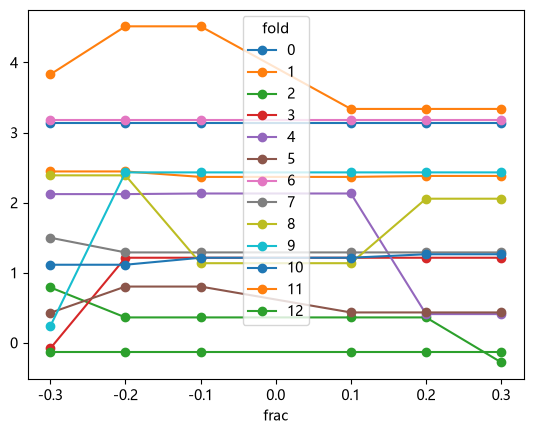

In [17]:
plt.show()

### Step 5｜双参数联合热力图（checklist 4.2）

- 返回 `{fold: DataFrame(index=frac_a, columns=frac_b), "mean": 跨折逐格平均}`。
- 读图：各档平缓 → 联合高原（稳健）；仅 (0,0) 突出 → 联合孤峰（脆弱）；
  对角陡峭 → 两参数互补/冲突（交互项存在）。

Fold 0: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 1: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 2: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 3: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 4: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 5: extremes__k×correlate__threshold 热力图 (5×5) 完成


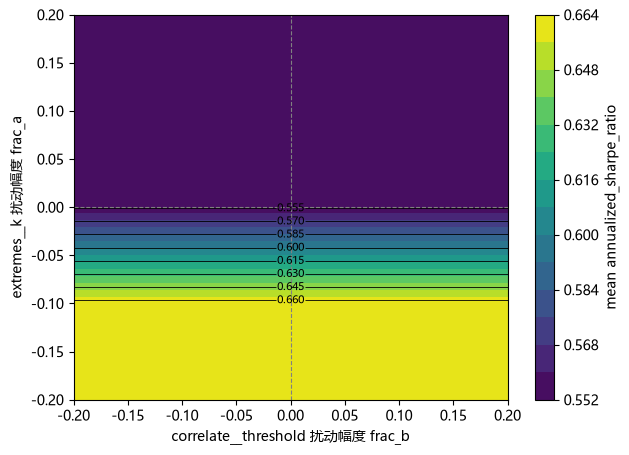

In [20]:
import numpy as np
import matplotlib.pyplot as plt

grids = sensitivity_heatmap(X, fold_results, param_a="extremes__k",
                            param_b="correlate__threshold",
                            reduce_test=False)
mean = grids["mean"]                          # 行=frac_a, 列=frac_b, 值=跨折平均ASR
Xg, Yg = np.meshgrid(mean.columns, mean.index)   # x=frac_b, y=frac_a，与 values[i,j] 对齐
fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(Xg, Yg, mean.values, levels=15, cmap="viridis")   # 彩色填充
cs = ax.contour(Xg, Yg, mean.values, levels=8, colors="k", linewidths=0.6)  # 等值线
ax.clabel(cs, inline=True, fontsize=8)        # 标数值
ax.axhline(0, color="gray", lw=0.8, ls="--")  # 生产值锚点十字线（0,0 = 未扰动）
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("correlate__threshold 扰动幅度 frac_b")
ax.set_ylabel("extremes__k 扰动幅度 frac_a")
fig.colorbar(cf, label="mean annualized_sharpe_ratio")
plt.show()

### Step 6｜消融实验

- 臂：`full`（基准）/ `no_extremes` / `no_nondomin` / `no_correlate` / `no_extremes_correlate`。
- 每臂 = 固定每折最优参数 × 剔除对应管线步骤 × CPCV 多路径压测（同窗同口径对比）。
- 判读：全臂样本路径数一致（每折 = `n_test_folds` 组合路径），绩效差距即模块边际贡献；
  某模块剔除后绩效**不降反升** → 该模块负贡献，考虑剔除后重搜（会作废旧 OOS）。

In [23]:
frames, summary = ablate(X, fold_results)                # arms=None = 全部 5 臂
summary

,说明,折数,天数,annualized_mean,annualized_sharpe_ratio,max_drawdown,skew,kurtosis
臂,,,,,,,,
full,全管线（基准）,6,1512,0.088016,0.894546,0.116472,-0.015145,10.549606
no_extremes,无峰度预筛（剔除 extremes 步骤）,6,1512,0.065866,0.862265,0.088719,0.338118,12.116282
no_nondomin,无非支配筛选（剔除 nondomin 步骤）,6,1512,0.078391,0.826661,0.105313,-0.492066,8.794570
no_correlate,无去相关（剔除 correlate 步骤）,6,1512,0.047202,0.364724,0.293147,-0.468442,6.853433
no_extremes_correlate,剔除 extremes + correlate,6,1512,0.093741,0.902705,0.196126,-0.646392,7.814286


In [24]:
log_result(summary.to_string(), section="消融实验")

### Step 7｜参数扰动蒙特卡洛 + 判定

In [ ]:
out = perturbation_mc(X, fold_results, fitness_topk=5)                   # R=None → ceil(500 / 折数)，总样本 ≥ 500

In [150]:
out['verdict']

,指标,样本数,prob>0,median,p95,通过
0,annualized_mean,507,0.903353,0.113004,0.316511,True
1,annualized_sharpe_ratio,507,0.903353,1.261678,3.139579,True


In [151]:
out['fold_summary']

,n,annualized_mean_mean,annualized_mean_median,annualized_mean_p5,annualized_mean_p95,annualized_sharpe_ratio_mean,annualized_sharpe_ratio_median,annualized_sharpe_ratio_p5,annualized_sharpe_ratio_p95,max_drawdown_mean,...,max_drawdown_p95,skew_mean,skew_median,skew_p5,skew_p95,kurtosis_mean,kurtosis_median,kurtosis_p5,kurtosis_p95,pos_prob
fold,,,,,,,,,,,,,,,,,,,,,
0,39,0.114112,0.052112,0.017740,0.396740,1.292467,1.046858,0.295861,3.139579,0.036794,...,0.054353,0.035468,0.242569,-0.726920,0.553630,6.161362,6.350444,5.386924,6.641066,1.000000
1,39,0.195789,0.211091,0.090474,0.288069,1.883484,1.904748,1.071884,2.735408,0.065966,...,0.084900,-0.212261,-0.253512,-0.449060,0.269177,4.041860,3.945983,3.697458,4.810543,0.974359
2,39,0.046928,0.042260,0.002194,0.167671,0.880226,0.738002,0.043091,2.021897,0.032544,...,0.070278,-0.176149,-0.204486,-0.502634,0.371917,4.022140,3.236600,2.566316,6.451092,0.948718
3,39,0.105298,0.113004,-0.021499,0.206258,2.029180,2.520180,-0.315142,3.648628,0.027009,...,0.062454,0.002319,0.097402,-0.371923,0.344133,5.147773,5.029438,3.082278,6.901054,0.923077
4,39,0.150439,0.274079,-0.265825,0.274087,1.184110,2.121271,-1.994514,2.130047,0.071298,...,0.188325,-0.114541,-0.094199,-0.508079,0.224505,4.287416,3.650374,3.082842,5.414486,0.820513
5,39,0.034034,0.035678,-0.043088,0.084941,0.278861,0.333539,-0.397490,0.676169,0.071297,...,0.086521,-0.426293,-0.505634,-0.744690,0.010939,4.645636,4.594550,3.328906,6.006268,0.846154
6,39,0.128697,0.127023,0.112960,0.159354,1.983736,1.667762,0.961118,3.177725,0.058187,...,0.106783,0.376001,0.392628,0.024525,0.494194,4.841346,5.233428,3.567264,5.620750,1.000000
7,39,0.068929,0.057047,-0.025251,0.131066,1.147436,1.190865,-0.480029,2.247332,0.033492,...,0.043910,-0.035558,0.031480,-0.280501,0.210641,3.895007,3.235186,2.608128,5.161216,0.871795
8,39,0.129383,0.136881,-0.003978,0.305578,1.874885,1.661872,-0.029823,3.241179,0.057772,...,0.126369,0.302549,0.516515,-0.173364,0.714591,5.078777,5.892025,2.591490,7.214605,0.820513


In [22]:
oos_pop = Population([fold['test'] for fold in fold_results])
oos_pop.plot_cumulative_returns()

In [23]:
oos_mpt = MultiPeriodPortfolio([fold['test'] for fold in fold_results],compounded=True)
oos_mpt.plot_cumulative_returns()

#### 路径采样

In [27]:
fold_paths = adaptive_multi_paths(X, fold_results, 
                                 test_size=search_params['test_size'], 
                                 train_size=search_params['train_size'],
                                 n_test_folds=search_params['n_test_folds'], n_jobs=8)

Fold 0: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 1: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 2: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 3: paths=5 | window=756 | inner_folds=6 | test_days=252
Fold 4: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 5: paths=4 | window=630 | inner_folds=5 | test_days=252


In [28]:
oos_blocks = build_test_parts(fold_paths, n_test_folds=search_params['n_test_folds'])
oos_paths = discrete_lhs_safe(oos_blocks, n_samples=1000, seed=42)
oos_mpts = Population([MultiPeriodPortfolio(path ,compounded=False) for path in oos_paths])

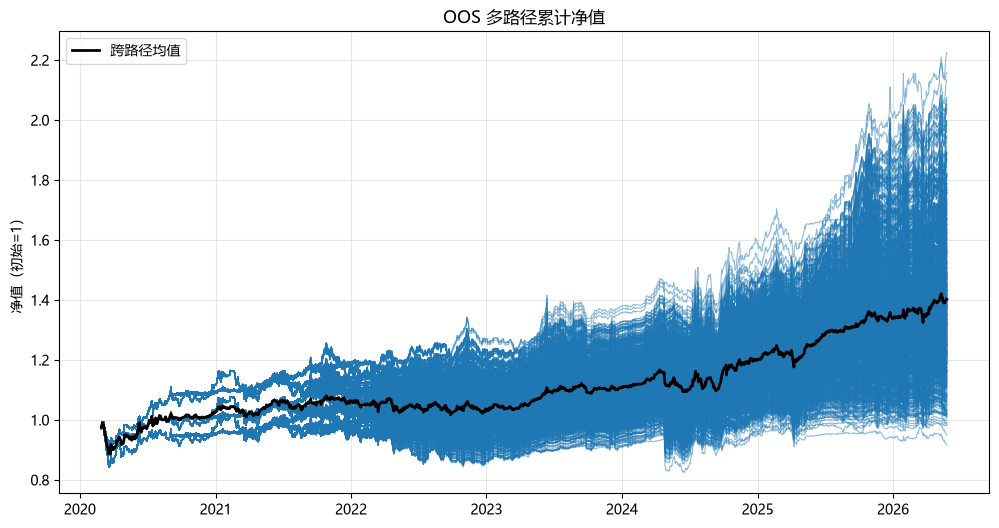

In [29]:
plot_paths_curve(oos_mpts)

In [24]:
log_print(oos_mpt.summary(),section='OSS Summary',echo=False)

### OOS诊断：
- Annualized Mean 分布
- PSR诊断
- 基准联动
- 换手频率

LHS多路径分布(1000条): 均值 0.0595 | 中位 0.0578 | 5% 0.0173 | 95% 0.1046
WF真实路径: 0.0887 | 分布中 1.10σ | 分位 85.2%


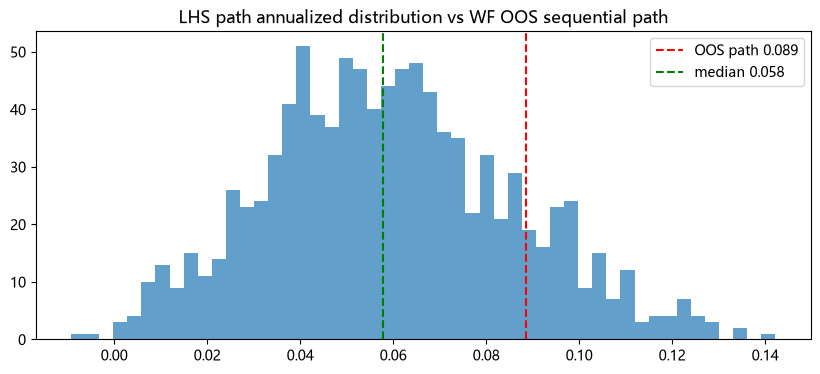

In [34]:
# 年化分布
path_anns = np.array([oos_mpt.annualized_mean for oos_mpt in oos_mpts])

oos_ann = oos_mpt.annualized_mean

report_ann_distribution(path_anns, oos_ann)

In [35]:
diagnose_result = diagnose_oos_lhs(lhs_paths=oos_paths)
del diagnose_result['mc_sharpes']
del diagnose_result['mc_mdds']
del diagnose_result['mc_psrs']
log_print(diagnose_result, section='OOS PSR Diagnose',echo=False)

[Info] 1000 LHS paths | OOS 1512 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 6.20%
  ✅ Sharpe 90% CI         : [-0.030, 0.813]
  ✅ MDD median / worst-5%  : 13.88% / 15.69%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 0.3833
  ⚠️ PSR(0) median / 5%    : 100.00% / 11.99%


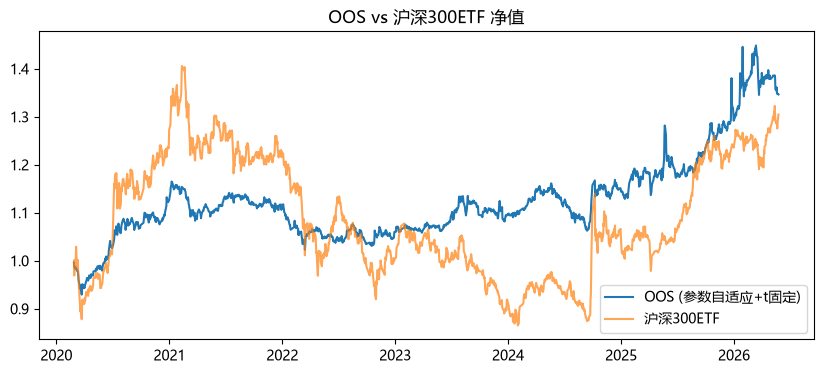

In [25]:
plot_oos_vs_bench(oos_mpt, bench_ret)

In [37]:

df_ex = excess_vs_bench(oos_mpts, bench_ret)
log_result(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4),
           section="OOS vs 沪深300 相对收益分布")

      ann_excess  arith_excess      IR  winrate
5%       -0.0278       -0.0416 -0.2651   0.5007
50%       0.0110       -0.0011 -0.0066   0.5119
95%       0.0557        0.0457  0.2956   0.5225
mean      0.0126        0.0006  0.0029   0.5120


### Simulation

In [26]:
from sl_simulation import load_sl_config, simulate_sl, summarize_sl

In [27]:
cfg  = load_sl_config()
cfg['space'] = search_space
cfg['search_kwargs'] = search_params
cfg['stop_loss'] = {'min_epoch_days': 0,
    'conditions': [{
        'name': 'epoch_dd',
        'metric': 'drawdown',
        'op': '<=',
        'threshold': -0.5}]}

In [ ]:
base = simulate_sl(X, folds=fold_results, cfg=cfg)

Epoch 0: 2020-02-27 -> 2021-03-10 (252d, expired) | src=fold_reuse | ASR=1.051 | 累计=9.18%
Epoch 1: 2021-03-11 -> 2022-03-23 (252d, expired) | src=fold_reuse | ASR=-0.456 | 累计=-3.27%
Epoch 2: 2022-03-24 -> 2023-04-06 (252d, expired) | src=fold_reuse | ASR=0.270 | 累计=1.27%
Epoch 3: 2023-04-07 -> 2024-04-22 (252d, expired) | src=fold_reuse | ASR=0.980 | 累计=6.65%
Epoch 4: 2024-04-23 -> 2025-05-09 (252d, expired) | src=fold_reuse | ASR=0.426 | 累计=3.69%
Epoch 5: 2025-05-12 -> 2026-05-25 (252d, expired) | src=fold_reuse | ASR=0.935 | 累计=13.86%
决策日 2026-05-25: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

In [43]:
res  = simulate_sl(X, cfg=cfg)

Epoch 0: 2020-02-27 -> 2021-03-10 (252d, expired) | src=fold_reuse | ASR=0.406 | 累计=5.18%
Epoch 1: 2021-03-11 -> 2022-03-23 (252d, expired) | src=fold_reuse | ASR=0.199 | 累计=0.57%
Epoch 2: 2022-03-24 -> 2023-04-06 (252d, expired) | src=fold_reuse | ASR=1.566 | 累计=6.00%
Epoch 3: 2023-04-07 -> 2024-04-22 (252d, expired) | src=fold_reuse | ASR=2.724 | 累计=9.97%
Epoch 4: 2024-04-23 -> 2025-05-09 (252d, expired) | src=fold_reuse | ASR=0.560 | 累计=5.68%
Epoch 5: 2025-05-12 -> 2026-05-25 (252d, expired) | src=fold_reuse | ASR=1.788 | 累计=26.86%
决策日 2026-05-25: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 6: 2026-05-26 -> 2026-08-14 (58d, end_of_data) | src=fresh | ASR=1.322 | 累计=3.29%


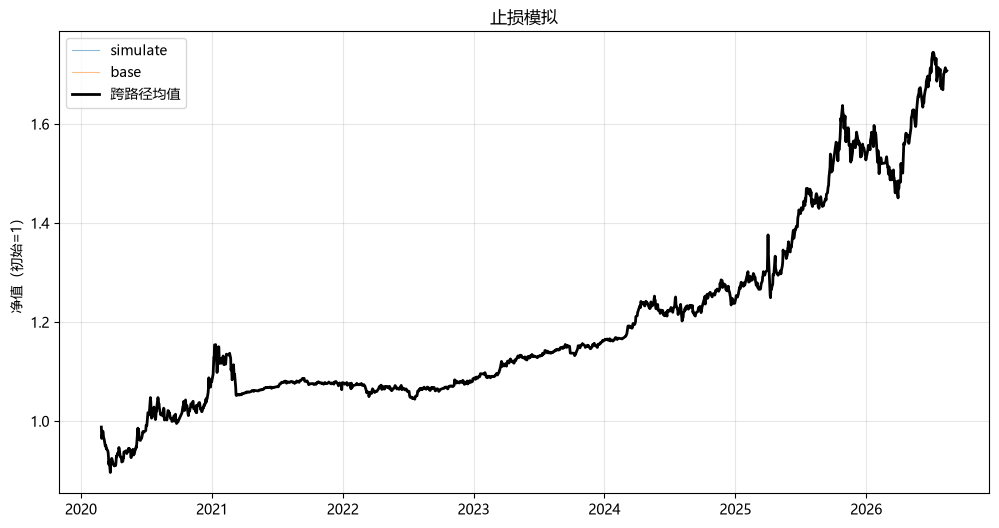

In [48]:
sl_mpts = Population([res['mpt'], oos_mpt])
plot_paths_curve(sl_mpts, title='止损模拟', labels=['simulate','base'])

In [ ]:
sl_mpts.plot_cumulative_returns()

In [ ]:
# 可选传基准供画图：simulate_sl(..., bench=bench_ret)，结果在 res["bench"]
cmp_tbl = summarize_sl(res, base)
cmp_tbl

In [58]:
print(res["daily"].loc[res["daily"]["trigger"] != ""])  # 仅触发日

                          date  epoch  day_in_epoch       ret  net_global  \
14   2020-03-18 00:00:00+08:00      0            15 -0.006880    0.897387   
1558 2026-07-30 00:00:00+08:00      7            32 -0.013579    1.445758   

      net_epoch  cum_epoch  dd_epoch  hit_epoch_dd   trigger  
14     0.897387  -0.102613 -0.100353          True  epoch_dd  
1558   0.924389  -0.075611 -0.104227          True  epoch_dd  


In [59]:
# 2) 落盘（与既有 log_result 体系一致）
log_result(cmp_tbl,         section="SL模拟 vs 无止损基线")
log_result(res["epochs"],   section="SL 模拟 epoch 明细")
log_result(res["triggers"], section="SL 触发明细")